# A checkout chart for *your* ability

Every checkout chart in every pub is the same chart. "170: T20 T20 Bull. 167:
T20 T19 Bull." It is computed for a player who hits what they aim at, and it
assumes everyone should play the same way. Both assumptions are wrong for
almost everyone holding it.

The solved MDP produces the correct chart for any ability. This notebook builds
them, and shows where the standard advice is wrong.

## Which model?

Three choices have to be justified, because they change the answer.

**Three darts, not one.** A chart is a *route for a visit*. Only the 3-dart
model knows that a bust on dart 1 forfeits the other two, and that the right
aim for the same score depends on which dart of the visit it is.

**Minimum visits, not minimum darts.** A chart is used in a match, and a match
is a race in visits. Under the per-dart objective a bust on dart 1 costs only
the single dart that was actually thrown, which under-penalises early busts.

**No opponent.** A chart cannot depend on the opponent's score without becoming
a two-dimensional table. Notebook 04 measured the cost of that simplification:
at most 1.4 points of win probability, and only in the endgame.

In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..', '..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25,
    'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 11, 'font.size': 9, 'legend.frameon': False,
})
pd.set_option('display.width', 200)

from darts import players
from darts.checkout import (chart_with_odds, compare_bands, disagreements,
                            policy_chart, route_chart)
from darts.mdp_3turn import ThreeDartMDP
from darts.transitions import transition_arrays

BANDS = list(players.ABILITY_BANDS)
models, points = {}, {}
for band in BANDS:
    sigma = players.ABILITY_BANDS[band]
    tr = transition_arrays(players.BOARD_PIXELS, sigma,
                           point_stride=players.POINT_STRIDE_SINGLE)
    models[band] = ThreeDartMDP(tr['probs'], tr['checkout_probs'],
                                tr['allowed_scores'], players.GAME_START,
                                dart_cost=0.0, turn_cost=1.0).solve()
    points[band] = tr['points']
    print(f"{band:>13}  sigma {sigma:>4} mm   "
          f"{players.three_dart_average(-models[band].V1[501] * 3):.0f} average"
          if False else f"{band:>13}  sigma {sigma:>4} mm   "
          f"{-models[band].V1[501]:.2f} visits to finish 501")

        elite  sigma  6.5 mm   5.32 visits to finish 501


          pro  sigma  8.0 mm   5.97 visits to finish 501


       county  sigma 10.0 mm   6.90 visits to finish 501


 super_league  sigma 13.0 mm   8.47 visits to finish 501


       league  sigma 16.0 mm   10.19 visits to finish 501


         club  sigma 20.0 mm   12.47 visits to finish 501


          pub  sigma 28.0 mm   17.02 visits to finish 501


## The chart for a league player

Alongside the route, the two numbers a player actually wants: the chance of
finishing this visit, and how many visits this score is worth.

In [2]:
band = 'league'
co_pct = np.load(f'{module_path}/results/single_player/{band}_visits.npz')['checkout_pct']
rows = chart_with_odds(models[band], points[band], players.BOARD_PIXELS, co_pct,
                       scores=[170, 161, 141, 121, 110, 100, 81, 70, 64, 50,
                               41, 40, 36, 32, 24, 20, 16, 10, 8, 6, 5, 4, 3, 2])
pd.DataFrame(rows).set_index('score')

,route,darts,route finishes,P(finish this visit),expected visits
score,,,,,
170,T19 T20 13,3,False,0.0000,4.856
161,T20 T19 12,3,False,0.0000,4.707
141,T20 T19 D12,3,True,0.0030,4.391
121,T19 T16 D8,3,True,0.0050,4.079
110,T19 13 D20,3,True,0.0313,3.895
100,T20 D20,2,True,0.0579,3.680
81,T19 D12,2,True,0.0663,3.484
70,T14 D14,2,True,0.1541,3.259
64,T16 D8,2,True,0.1817,3.137


Three things a printed chart cannot tell you, all visible here.

**The big finishes are not finishes.** At 170 and 161 the model does not
attempt a checkout at all -- the chance is essentially zero, so it just scores.
A chart that prints "170: T20 T20 Bull" is describing something this player
should not try.

**"outside D5" is real advice.** It means aim at the *outer edge* of the double,
not at its middle. Missing a double inwards leaves an odd number; missing
outwards leaves the score untouched. For a weaker player that trade is worth
taking, and it is the single most common way these charts differ from the
printed one.

**The odds are sobering.** A league player finishes 40 in a visit 42% of the
time, and 100 only 6%.

## What changes with ability

In [3]:
scores = [170, 141, 110, 100, 81, 64, 50, 40, 36, 32, 24, 20, 16, 10, 8, 6, 4, 2]
pd.DataFrame(compare_bands(models, points, players.BOARD_PIXELS, scores)
             ).set_index('score')

,elite,pro,county,super_league,league,club,pub
score,,,,,,,
170,T20,T20,T20,T20,T19,19,T19
141,BULL,BULL,T20,T20,T20,19,T19
110,T18,T18,T18,T20,T19,19,T19
100,T20,T20,T20,T20,T20,20,20
81,T19,T19,BULL,BULL,T19,T19,T14
64,T16,T16,T16,T16,T16,16,16
50,18,18,18,18,18,18,18
40,D20,D20,D20,D20,D20,D20,outside D20
36,D18,D18,D18,D18,D18,D18,outside D18


The scoring end of the chart is nearly ability-independent -- everyone goes at
the treble 20 or the treble 19. The checkout end is not.

band,elite,pro,county,super_league,league,club,pub
scores differing from elite,0,15,27,46,65,115,119


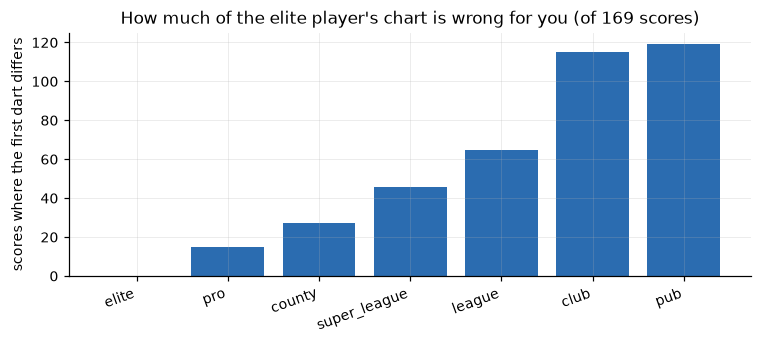

In [4]:
d = pd.DataFrame(disagreements(models, points, players.BOARD_PIXELS,
                               reference='elite', scores=range(2, 171)))
counts = d.groupby('band').size().reindex(BANDS).fillna(0).astype(int)
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(range(len(counts)), counts.values, color='#2b6cb0')
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(counts.index, rotation=20, ha='right')
ax.set_ylabel('scores where the first dart differs')
ax.set_title("How much of the elite player's chart is wrong for you (of 169 scores)")
fig.tight_layout()
counts.to_frame('scores differing from elite').T

## Where the last dart of a visit differs from the first

This is the part no printed chart has room for: on the last dart of a visit
there is nothing left to set up, and the only thing that matters is the score
you leave behind.

In [5]:
rows = []
for band in ['elite', 'league', 'pub']:
    ch = pd.DataFrame(policy_chart(models[band], points[band],
                                   players.BOARD_PIXELS, range(2, 61)))
    ch['band'] = band
    rows.append(ch)
allp = pd.concat(rows)
differs = allp[allp['dart 1'] != allp['dart 3']]
print(f"scores 2-60 where dart 3 differs from dart 1:")
print(differs.groupby('band').size().reindex(['elite', 'league', 'pub']).to_string())
differs[differs.band.isin(['league', 'pub'])].set_index(['band', 'score']).head(20)

scores 2-60 where dart 3 differs from dart 1:
band
elite      2
league     7
pub       16


dart 1      dart 2       dart 3
band   score                                     
league 2      outside D1  outside D1           D1
       4              D2          D2   outside D2
       6      outside D3          D3            2
       25              9           9           17
       26            D13         D13  outside D13
       30            D15         D15  outside D15
       33              1           1           17
pub    2      outside D1  outside D1           D1
       3      outside D1           1            1
       6      outside D3  outside D3            2
       8      outside D4  outside D4           D4
       10     outside D5  outside D5            2
       14     outside D7  outside D7            6
       15             11          11            7
       17              9           9            1
       29             13          13            3
       31            T19          19           19
       37              5           5            3
       39              7           7          T19
       41              9           9            3

## Summary

* A checkout chart is a 3-dart, minimum-visits object, and the model produces
  one per ability.
* The scoring half of the chart is common to everyone; the checkout half is not.
* For weaker players, a lot of the standard chart is actively wrong -- most
  often because it says to go at a double when the model says protect the
  number.